<a href="https://colab.research.google.com/github/KarthikSaravanakumarM56/24ADI003-24BAD056/blob/main/Scenario2_Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scenario 2 - Boosting (AdaBoost & Gradient Boosting)
### Predicting Customer Churn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_curve, auc

In [2]:
df = pd.read_csv("churn_boosting.csv")
print(df.shape)
df.head()

(120, 5)


,Tenure,MonthlyCharges,ContractType,InternetService,Churn
0,65,105.22,Two year,NaN,0
1,17,75.19,Month-to-month,NaN,0
2,71,76.09,Two year,Fiber optic,0
3,45,107.67,Two year,Fiber optic,0
4,4,60.35,Two year,NaN,0


In [3]:
# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

X = df.drop("Churn", axis=1)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# AdaBoost
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
ada_acc = accuracy_score(y_test, ada.predict(X_test))
print(f"AdaBoost Accuracy: {ada_acc:.4f}")

AdaBoost Accuracy: 1.0000


In [5]:
# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_acc = accuracy_score(y_test, gb.predict(X_test))
print(f"Gradient Boosting Accuracy: {gb_acc:.4f}")

Gradient Boosting Accuracy: 1.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


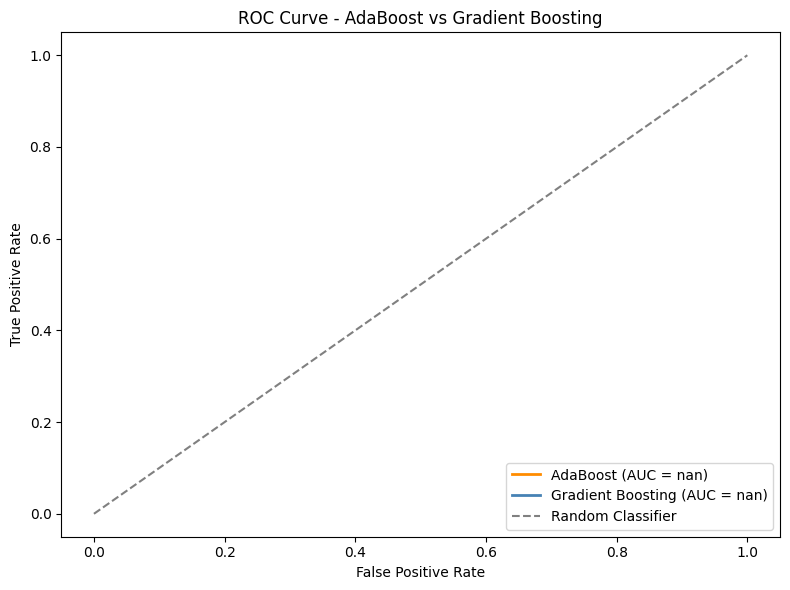

In [6]:
# ROC Curve for both models
ada_probs = ada.predict_proba(X_test)[:, 1]
gb_probs = gb.predict_proba(X_test)[:, 1]

fpr_ada, tpr_ada, _ = roc_curve(y_test, ada_probs)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_probs)

auc_ada = auc(fpr_ada, tpr_ada)
auc_gb = auc(fpr_gb, tpr_gb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_ada, tpr_ada, color="darkorange", lw=2, label=f"AdaBoost (AUC = {auc_ada:.3f})")
plt.plot(fpr_gb, tpr_gb, color="steelblue", lw=2, label=f"Gradient Boosting (AUC = {auc_gb:.3f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - AdaBoost vs Gradient Boosting")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("scenario2_roc.png", dpi=100)
plt.show()

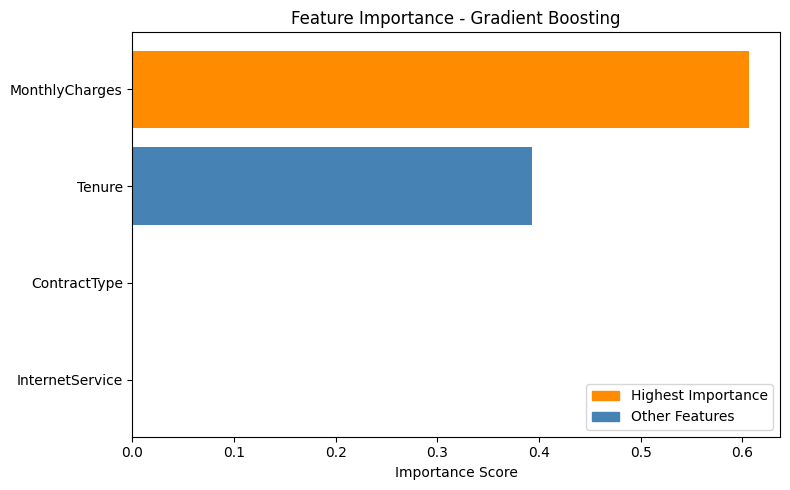

In [7]:
# Feature Importance - Gradient Boosting
feat_imp = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
colors = ["steelblue" if v < feat_imp.max() else "darkorange" for v in feat_imp]
bars = plt.barh(feat_imp.index, feat_imp.values, color=colors)
plt.xlabel("Importance Score")
plt.title("Feature Importance - Gradient Boosting")
# manual legend
import matplotlib.patches as mpatches
high = mpatches.Patch(color="darkorange", label="Highest Importance")
low = mpatches.Patch(color="steelblue", label="Other Features")
plt.legend(handles=[high, low], loc="lower right")
plt.tight_layout()
plt.savefig("scenario2_feat_imp.png", dpi=100)
plt.show()